Сделано с асгардархеей.

In [5]:
!pip install Bio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 321.3/321.3 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 53.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 3.4 MB/s eta 0:00:00


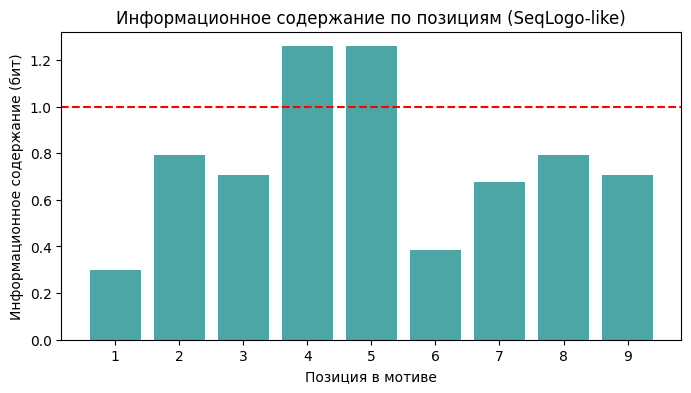

Позиция 1: IC = 0.30 бит
Позиция 2: IC = 0.79 бит
Позиция 3: IC = 0.71 бит
Позиция 4: IC = 1.26 бит
Позиция 5: IC = 1.26 бит
Позиция 6: IC = 0.39 бит
Позиция 7: IC = 0.68 бит
Позиция 8: IC = 0.79 бит
Позиция 9: IC = 0.71 бит

Итоговый кор-мотив находится в позициях: [4, 5]
Анализ структуры мотива
Позиция 1: 0.30 бит -> Вариация
Позиция 2: 0.79 бит -> Вариация
Позиция 3: 0.71 бит -> Вариация
Позиция 4: 1.26 бит -> Кор
Позиция 5: 1.26 бит -> Кор
Позиция 6: 0.39 бит -> Вариация
Позиция 7: 0.68 бит -> Вариация
Позиция 8: 0.79 бит -> Вариация
Позиция 9: 0.71 бит -> Вариация


In [13]:
import numpy as np
import matplotlib.pyplot as plt
from Bio import motifs
from Bio.Seq import Seq

m = motifs.create([Seq(s) for s in sites])
ppm = m.counts.normalize(pseudocounts=0.5)

length = m.length
positions = range(1, length + 1)
entropies = []
ics = []

for i in range(length):
    col_probs = [ppm[base][i] for base in 'ACGT']

    h = -sum([p * np.log2(p) for p in col_probs if p > 0])
    entropies.append(h)
    ic = 2 - h
    ics.append(ic)

plt.figure(figsize=(8, 4))
plt.bar(positions, ics, color='teal', alpha=0.7)
plt.axhline(y=1, color='red', linestyle='--', label='Средний уровень')
plt.xlabel('Позиция в мотиве')
plt.ylabel('Информационное содержание (бит)')
plt.title('Информационное содержание по позициям (SeqLogo-like)')
plt.xticks(positions)
plt.show()

for pos, ic in zip(positions, ics):
    print(f"Позиция {pos}: IC = {ic:.2f} бит")


print(f"\nИтоговый кор-мотив находится в позициях: {core_positions}")

print("Анализ структуры мотива")
for pos, ic in zip(positions, ics):
    status = "Кор" if ic > 1.2 else "Вариация"
    print(f"Позиция {pos}: {ic:.2f} бит -> {status}")


Кор-мотив находится в позициях 4 и 5. Эти позиции имеют наивысшее информационное содержание ($IC = 1.26$ бит), что значительно выше среднего уровня (отмеченного красной линией в $1.0$ бит). Это указывает на высокую консервативность и важность данных позиций для связывания.

Расчет совпадает с визуальным анализом. На графике четко видно кор-мотива в центре (4–5 позиции), в то время как края значительно отличаются по значению.